In [22]:
import pymc as pm
import arviz as az
import numpy as np
import pytensor as pt
import pytensor.tensor as tt
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
s = []
for i in np.arange(347):
    s.append(str(i))

In [3]:
data = pd.read_csv('EVI.csv', header=0, names=s)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,337,338,339,340,341,342,343,344,345,346
0,0.4560,NaN,0.3975,0.3183,0.3022,0.2870,0.2886,0.2236,0.2318,0.1911,...,0.2832,0.3471,0.3432,NaN,0.3971,0.4401,0.3606,0.3702,0.4172,0.4218
1,0.4652,NaN,0.3807,0.3194,0.2936,0.2985,0.2810,0.2221,0.2281,0.1891,...,0.2933,0.3547,0.3450,NaN,0.4069,0.4418,0.3606,0.3621,NaN,0.4294
2,0.4642,NaN,0.3748,0.3107,0.2918,0.3008,0.2810,0.2221,0.2277,0.1851,...,0.2804,0.3445,0.3450,NaN,0.4032,0.4490,0.3527,0.3750,NaN,0.4099
3,0.4576,NaN,0.3624,0.3076,0.2811,0.3083,0.2754,0.2134,0.2194,0.1820,...,0.2998,0.3517,0.3450,NaN,0.4006,0.4494,0.3551,0.3586,NaN,0.4326
4,0.4468,NaN,0.3600,0.2974,0.2681,0.3129,0.2698,0.2099,0.2194,0.1773,...,0.2891,0.3464,0.3468,NaN,0.3861,0.4378,0.3388,0.3273,NaN,0.4228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,0.4263,NaN,0.3711,0.3008,0.2867,0.3200,0.2856,0.2336,0.2417,0.2061,...,0.3174,0.4838,0.2843,NaN,0.3790,0.4730,0.4753,0.3612,0.4667,0.4319
11296,0.4412,NaN,0.3804,0.3055,0.3123,0.2833,0.2856,0.2278,0.2267,0.1967,...,0.2627,0.2769,0.1956,NaN,0.1590,0.3577,0.3272,0.6130,0.8339,0.6045
11297,0.4610,NaN,0.3835,0.3165,0.3134,0.2578,0.2923,0.2326,0.2267,0.1927,...,0.1562,0.1554,0.1581,NaN,0.1512,0.1602,0.3670,0.6244,0.8663,0.7845
11298,0.4566,NaN,0.3876,0.3174,0.3208,0.2883,0.2869,0.2288,0.2263,0.1930,...,0.1645,0.1945,0.1680,NaN,0.2586,NaN,0.3687,0.5850,0.5896,0.7060


In [5]:
def inpaint_nans(data):
    """
    Inpaint NaNs in a DataFrame using linear interpolation.
    """
    #return data.interpolate(method='linear', limit_direction='both', axis=0)
    aux = data.interpolate(method='linear', limit_direction='both', axis=0)
    return aux.interpolate(method='linear', limit_direction='both', axis=1)

ploteo datos de verdad

"Legacy"

In [6]:
''' 
#%% Model definition
basic_model = pm.Model()
samplesPerYear = 23 #Number of datapoints per year
sigma_err_prior = 1/0.05 #Estimate of EVI error variance
dummyData = np.zeros([0])
shared_data = T.shared(dummyData, borrow=True) #Sahred data definition - Theano

#%% Model definition
with basic_model:
        ## prior for 15-day EVI, U(0-1)
        x = pm.Uniform("x", 0, 1, shape=samplesPerYear)
        x = Tensor.cast(x, 'float64') #required for theano
        
        ## prior for observation process, Exp(sigma_err_prior)
        sigma_err = pm.Exponential("sigma_err", sigma_err_prior)

        @T.compile.ops.as_op(itypes=[Tensor.dvector],otypes=[Tensor.dvector]) #original
        def loredo(x = x, profile=True):
            L = shared_data.get_value(borrow=True).shape[0]
            out = np.zeros(L)
            k = 0
            while True:
                if (k+1)*samplesPerYear < L:
                    out[k*samplesPerYear:(k+1)*samplesPerYear] = x[0:samplesPerYear]
                    k = k+1
                else:
                    diff = (k+1)*samplesPerYear - L
                    out[k*samplesPerYear:(k+1)*samplesPerYear-diff] = x[0:samplesPerYear-diff]
                    break
            return out  
        loredo.grad = lambda *y: y[0]  # Here's the klutz, llama al grad pero es un bug
        loredo.shape = shared_data.get_value(borrow=True).shape[0]    
               
        ## likelihood
        observation = pm.Normal("obs", mu=loredo(x), tau=1/sigma_err, observed=shared_data)
'''

' \n#%% Model definition\nbasic_model = pm.Model()\nsamplesPerYear = 23 #Number of datapoints per year\nsigma_err_prior = 1/0.05 #Estimate of EVI error variance\ndummyData = np.zeros([0])\nshared_data = T.shared(dummyData, borrow=True) #Sahred data definition - Theano\n\n#%% Model definition\nwith basic_model:\n        ## prior for 15-day EVI, U(0-1)\n        x = pm.Uniform("x", 0, 1, shape=samplesPerYear)\n        x = Tensor.cast(x, \'float64\') #required for theano\n        \n        ## prior for observation process, Exp(sigma_err_prior)\n        sigma_err = pm.Exponential("sigma_err", sigma_err_prior)\n\n        @T.compile.ops.as_op(itypes=[Tensor.dvector],otypes=[Tensor.dvector]) #original\n        def loredo(x = x, profile=True):\n            L = shared_data.get_value(borrow=True).shape[0]\n            out = np.zeros(L)\n            k = 0\n            while True:\n                if (k+1)*samplesPerYear < L:\n                    out[k*samplesPerYear:(k+1)*samplesPerYear] = x[0:sam

Version 2025

defino subset de datos para probar

In [9]:
nPixelsWindow = 10
trainWindowLength = 90
samplesPerYear = 23

In [10]:
dataSubset = data.iloc[:nPixelsWindow, :trainWindowLength]

In [11]:
dataSubset = inpaint_nans(dataSubset)

chequeo que no haya NaNs

In [12]:
np.isnan(dataSubset).sum().sum()

0

In [13]:
dataSubset.shape

(10, 90)

In [14]:
coords = {'timeSeriesTrainlength': np.arange(trainWindowLength),
          'pixel': np.arange(nPixelsWindow),
          'samplesPerYear': np.arange(samplesPerYear)}
t = trainWindowLength
selPixel = 4

In [15]:
coords

{'timeSeriesTrainlength': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
        85, 86, 87, 88, 89]),
 'pixel': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 'samplesPerYear': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22])}

version normales correlacionadas pixel per pixel

In [16]:
dataSubset.iloc[selPixel,:].values

array([0.4468 , 0.4034 , 0.36   , 0.2974 , 0.2681 , 0.3129 , 0.2698 ,
       0.2099 , 0.2194 , 0.1773 , 0.1775 , 0.1786 , 0.1787 , 0.1981 ,
       0.2326 , 0.2428 , 0.3508 , 0.3123 , 0.3536 , 0.3585 , 0.3634 ,
       0.4133 , 0.4005 , 0.4038 , 0.3657 , 0.3392 , 0.3669 , 0.3327 ,
       0.32   , 0.30915, 0.2983 , 0.25125, 0.2042 , 0.1894 , 0.1904 ,
       0.1933 , 0.2031 , 0.2655 , 0.3353 , 0.3856 , 0.4216 , 0.4296 ,
       0.3589 , 0.4309 , 0.3686 , 0.3866 , 0.4387 , 0.3319 , 0.3514 ,
       0.313  , 0.3522 , 0.3143 , 0.3007 , 0.2871 , 0.2441 , 0.2228 ,
       0.2298 , 0.21955, 0.2093 , 0.2319 , 0.3263 , 0.418  , 0.4433 ,
       0.46665, 0.49   , 0.524  , 0.4174 , 0.3923 , 0.3714 , 0.3679 ,
       0.4045 , 0.3864 , 0.3546 , 0.3346 , 0.3123 , 0.3255 , 0.2756 ,
       0.2643 , 0.2523 , 0.2421 , 0.2293 , 0.23815, 0.247  , 0.3362 ,
       0.3585 , 0.3883 , 0.3595 , 0.4333 , 0.4395 , 0.4457 ])

In [17]:
#%% Model definition
sigma_err = 0.05

with pm.Model() as modeNormCorr:
        
        cov = np.eye(samplesPerYear)
        L, corr, std = pm.LKJCholeskyCov('packed_L', n=samplesPerYear, eta=1, sd_dist=pm.Exponential.dist(1.))
        cov = pm.Deterministic('cov', L.dot(L.T))

        # mu = 0.3 + np.zeros(samplesPerYear)
        mus = pm.Normal('mus', mu=0.3, sigma=0.1, shape=samplesPerYear)
        x = pm.MvNormal("x", mu=mus, cov=cov)
        # y = pm.Uniform("y", 0, 1, shape=0)
        y = []
        # print(x[0:4].eval())
        # print(samplesPerYear)

        ciclos = (t) // (samplesPerYear)
        resto = (t) % (samplesPerYear)

        # print(ciclos)
        # print(resto)

        for i in range(ciclos):
            # y = pm.math.concatenate([y, x], axis=0) 
            y = pm.math.concatenate([y, x], axis=0) 
        
        y = pm.math.concatenate([y, x[0:resto]], axis=0)
        # print(x.shape.eval())
        obs = pm.Normal("obs", mu=y, sigma=sigma_err, observed=dataSubset.iloc[selPixel,:].values)

In [18]:
with modeNormCorr:
    trace_modeNormCorr = pm.sample(target_accept=0.9)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [packed_L, mus, x]


/home/fran/miniconda3/envs/PyMC5/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 266 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 1466 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `t

estudio la traza

In [23]:
az.summary(trace_modeNormCorr, round_to=2)

/home/fran/miniconda3/envs/PyMC5/lib/python3.11/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning:

invalid value encountered in scalar divide



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mus[0],0.33,0.09,0.17,0.48,0.01,0.01,107.83,2300.87,1.03
mus[1],0.33,0.08,0.16,0.49,0.00,0.00,725.02,1289.39,1.01
mus[2],0.32,0.08,0.17,0.46,0.00,0.00,483.66,1688.44,1.01
mus[3],0.32,0.08,0.18,0.46,0.01,0.01,75.82,56.84,1.04
mus[4],0.31,0.07,0.16,0.45,0.00,0.00,1318.15,1636.56,1.01
...,...,...,...,...,...,...,...,...,...
"cov[22, 18]",0.00,0.11,-0.14,0.13,0.00,0.00,1822.35,320.51,1.04
"cov[22, 19]",0.00,0.12,-0.14,0.17,0.00,0.01,2520.70,164.74,1.06
"cov[22, 20]",-0.00,0.12,-0.21,0.19,0.00,0.01,2809.62,195.04,1.12
"cov[22, 21]",0.00,0.07,-0.08,0.07,0.00,0.00,3356.83,157.13,1.08


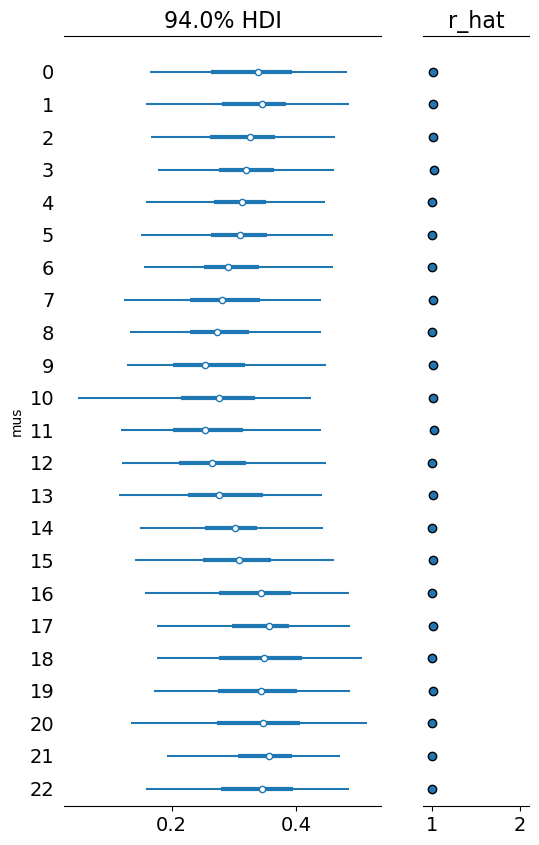

In [26]:
ax = az.plot_forest(
    trace_modeNormCorr,
    var_names=["mus"],
    r_hat=True,
    combined=True,
    figsize=(6, 10),
    labeller=az.labels.NoVarLabeller(),
)
ax[0].set_ylabel("mus");

evaluo matriz de corelacion

In [27]:
cov_trace = trace_modeNormCorr.posterior.cov.stack(dim=['chain', 'draw']).values
cov_trace_mean = cov_trace.mean(axis=2)

In [28]:
import plotly.express as px

fig = px.imshow(cov_trace_mean)
fig.show()

prediccion

In [29]:
with modeNormCorr:
    ppc_modeNormCorr = pm.sample_posterior_predictive(trace_modeNormCorr, var_names=["obs"])

Sampling: [obs]


### version normales correlacionadas basadas en (https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/multilevel_modeling.html)

In [30]:
#%% Model definition
sigma_err = 0.05

with pm.Model(coords=coords) as HierarchichalModel:
        
        '''
         floor_idx = pm.MutableData("floor_idx", floor_measure, dims="obs_id")
        county_idx = pm.MutableData("county_idx", county, dims="obs_id")

        # Priors
        mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0)
        sigma_a = pm.Exponential("sigma_a", 1)

        mu_b = pm.Normal("mu_b", mu=0.0, sigma=10.0)
        sigma_b = pm.Exponential("sigma_b", 1)

        # Random intercepts
        alpha = pm.Normal("alpha", mu=mu_a, sigma=sigma_a, dims="county")
        # Random slopes
        beta = pm.Normal("beta", mu=mu_b, sigma=sigma_b, dims="county")

        # Model error
        sigma_y = pm.Exponential("sigma_y", 1)

        # Expected value
        y_hat = alpha[county_idx] + beta[county_idx] * floor_idx

        # Data likelihood
        y_like = pm.Normal("y_like", mu=y_hat, sigma=sigma_y, observed=log_radon, dims="obs_id")
            '''

        L, corr, std = pm.LKJCholeskyCov('packed_L', n=samplesPerYear, eta=1, sd_dist=pm.Exponential.dist(1.))
        cov = pm.Deterministic('cov', L.dot(L.T))

        #mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0, dims=("samplesPerYear"))
        #sigma_a = pm.Exponential("sigma_a", 1, dims=("samplesPerYear"))

        mu_a = pm.Normal("mu_a", mu=0.0, sigma=10.0) #, dims=("samplesPerYear"))
        sigma_a = pm.Exponential("sigma_a", 1) #, dims=("samplesPerYear"))
    
        mus = pm.Normal('mus', mu=mu_a, sigma=sigma_a, dims=('pixel',"samplesPerYear"))
        x = pm.MvNormal("x", mu=mus, cov=cov)

        #print(x.shape.eval())

        # y = pm.Uniform("y", 0, 1, shape=0)

        # print(x[0:4].eval())
        # print(samplesPerYear)

        ciclos = (t) // (samplesPerYear)
        resto = (t) % (samplesPerYear)

        #print(ciclos)
        #print(resto)

        y = x
        for i in range(ciclos-1): 
            #y = pm.math.concatenate([y, x], axis=0) #oiginal
            y = pm.math.concatenate([y, x], axis=1) 
        
        z = pm.math.concatenate([y, x[:,0:resto]], axis=1)
        #print(y.shape.eval())
        #print(x[:,0:resto].shape.eval())
        #print(z.shape.eval())
        obs = pm.Normal("obs", mu=z, sigma=sigma_err, observed=dataSubset, dims=('pixel','timeSeriesTrainlength'))

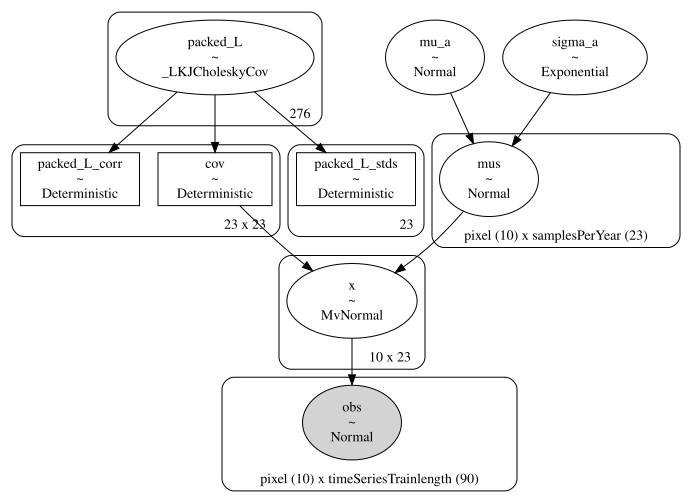

In [31]:
pm.model_to_graphviz(HierarchichalModel)

In [32]:
with HierarchichalModel:
    print(z.shape.eval())
    print(z.shape.eval() == dataSubset.shape)


[10 90]
[ True  True]


In [33]:
with HierarchichalModel:
    pm.sample_prior_predictive()

Sampling: [mu_a, mus, obs, packed_L, sigma_a, x]


In [34]:
with HierarchichalModel:
    trace_HierarchichalModel = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [packed_L, mu_a, sigma_a, mus, x]


/home/fran/miniconda3/envs/PyMC5/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning:

invalid value encountered in accumulate

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 560 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 595 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


evaluo traza

In [35]:
az.summary(trace_HierarchichalModel, round_to=2)

/home/fran/miniconda3/envs/PyMC5/lib/python3.11/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning:

invalid value encountered in scalar divide



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,0.34,0.01,0.32,0.36,0.0,0.0,5.85,23.18,1.83
"mus[0, 0]",0.34,0.01,0.32,0.36,0.0,0.0,6.28,23.75,1.70
"mus[0, 1]",0.34,0.01,0.32,0.36,0.0,0.0,6.29,27.45,1.70
"mus[0, 2]",0.34,0.01,0.32,0.36,0.0,0.0,6.27,27.82,1.69
"mus[0, 3]",0.34,0.01,0.32,0.36,0.0,0.0,6.30,26.75,1.69
...,...,...,...,...,...,...,...,...,...
"cov[22, 18]",0.00,0.00,-0.00,0.00,0.0,0.0,88.40,1072.58,1.03
"cov[22, 19]",0.00,0.00,-0.00,0.00,0.0,0.0,154.25,1372.66,1.03
"cov[22, 20]",0.00,0.00,-0.00,0.00,0.0,0.0,93.73,1164.79,1.04
"cov[22, 21]",0.00,0.00,-0.00,0.00,0.0,0.0,68.53,1145.63,1.04


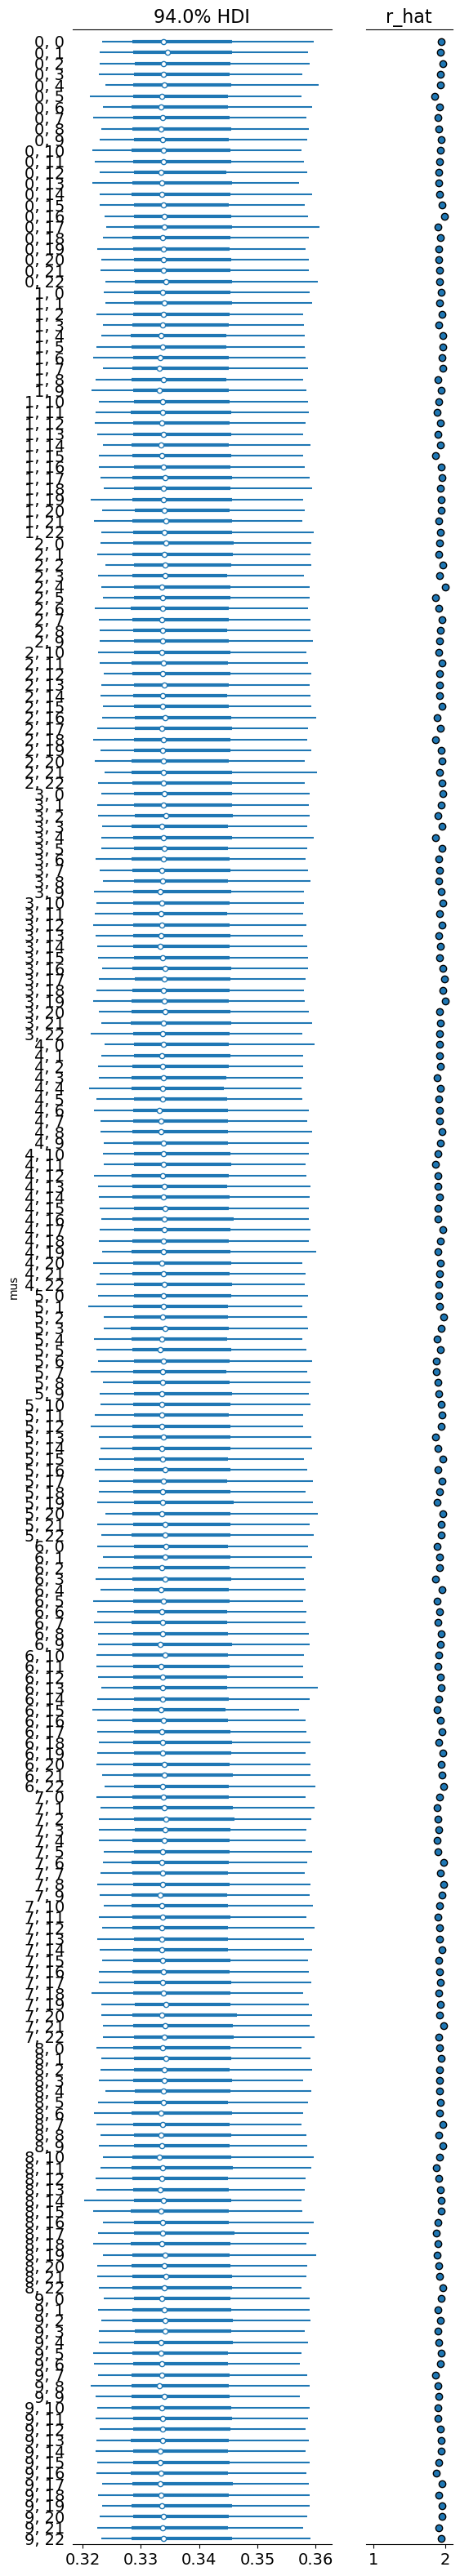

In [36]:
ax = az.plot_forest(
    trace_HierarchichalModel,
    var_names=["mus"],
    r_hat=True,
    combined=True,
    figsize=(6, 40),
    labeller=az.labels.NoVarLabeller(),
)
ax[0].set_ylabel("mus");

Evaluo como da la posterior de la matriz de covarianza (que se supone que es la posta de este modelo) 

In [37]:
#cov_trace = trace.posterior.cov.stack(dim=['chain', 'draw']).values
cov_trace = trace_HierarchichalModel.posterior.cov.stack(stacked=['chain', 'draw']).values
cov_trace_mean = cov_trace.mean(axis=2)

In [38]:
import plotly.express as px

fig = px.imshow(cov_trace_mean)
fig.show()

No parece haber grandes valores fuera de la diagonal :(

Prediccion

In [39]:
with HierarchichalModel:
    ppc_HierarchichalModel = pm.sample_posterior_predictive(trace_HierarchichalModel, var_names=["obs"])

Sampling: [obs]


In [40]:
ppc_HierarchichalModel.posterior_predictive.obs

<xarray.DataArray 'obs' (chain: 4, draw: 1000, pixel: 10,
                         timeSeriesTrainlength: 90)>
array([[[[0.44152877, 0.29275299, 0.26643671, ..., 0.32821245,
          0.38223524, 0.31628439],
         [0.41182475, 0.34586215, 0.34587633, ..., 0.34564742,
          0.44429414, 0.34473131],
         [0.37672022, 0.38818562, 0.38487761, ..., 0.44262033,
          0.36667372, 0.43460065],
         ...,
         [0.40612096, 0.31897108, 0.29448603, ..., 0.35075389,
          0.3842865 , 0.35236756],
         [0.43531406, 0.43839727, 0.31251164, ..., 0.51684282,
          0.38850133, 0.40358965],
         [0.55925049, 0.3964725 , 0.36830232, ..., 0.41261864,
          0.34541139, 0.42108847]],

        [[0.39353642, 0.45098526, 0.33465327, ..., 0.36270688,
          0.46935318, 0.48208701],
         [0.3831688 , 0.3893644 , 0.31814439, ..., 0.38663175,
          0.38637218, 0.48198352],
         [0.44548358, 0.29163092, 0.3664775 , ..., 0.45434959,
          0.34818513, 0.35537623],
...
         [0.418305  , 0.33202811, 0.28930786, ..., 0.39148757,
          0.42245944, 0.39474157],
         [0.46288341, 0.4113299 , 0.41264369, ..., 0.45450709,
          0.39940295, 0.45607816],
         [0.39175137, 0.35084821, 0.31300318, ..., 0.33602881,
          0.43701291, 0.47456849]],

        [[0.35090634, 0.39947098, 0.39810064, ..., 0.42537656,
          0.49578581, 0.45866344],
         [0.40930338, 0.42775362, 0.34426451, ..., 0.34906429,
          0.46817865, 0.41131132],
         [0.46134069, 0.40060063, 0.37314174, ..., 0.49346547,
          0.36751379, 0.45165593],
         ...,
         [0.36576582, 0.46208544, 0.39996676, ..., 0.36844041,
          0.41996444, 0.48430633],
         [0.46012576, 0.38716649, 0.47305538, ..., 0.45833821,
          0.40490095, 0.37868549],
         [0.48777259, 0.51667652, 0.33210135, ..., 0.42963485,
          0.40865746, 0.41178203]]]])
Coordinates:
  * chain                  (chain) int64 0 1 2 3
  * draw                   (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
  * pixel                  (pixel) int64 0 1 2 3 4 5 6 7 8 9
  * timeSeriesTrainlength  (timeSeriesTrainlength) int64 0 1 2 3 ... 86 87 88 89

<ErrorbarContainer object of 3 artists>

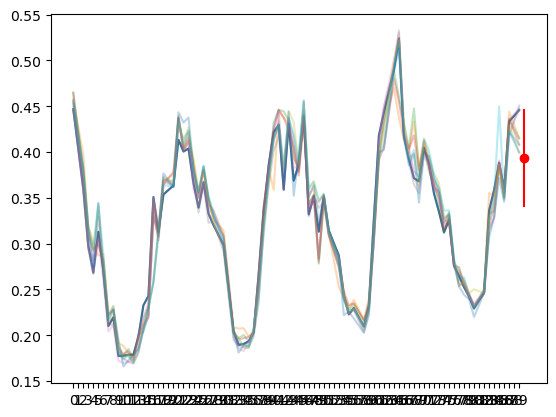

In [41]:
# fecha_est = (t+1) % (samplesPerYear) #estimacion t+1
fecha_est = (t) % (samplesPerYear)

# est_ = ppc.posterior_predictive.obs.stack(dim=['chain', 'draw']).values
# est_ = ppc.posterior_predictive.obs.stack(stacked=['chain', 'draw']).values
# est = est_[fecha_est,:]



est_HierarchichalModel = ppc_HierarchichalModel.posterior_predictive.obs.stack(stacked=['chain', 'draw']).sel(pixel = selPixel).sel(timeSeriesTrainlength = fecha_est)


plt.plot(dataSubset.iloc[selPixel,:])
plt.plot(dataSubset.T, alpha = 0.3)

plt.errorbar(x=t, y=est_HierarchichalModel.mean(), yerr=est_HierarchichalModel.std(), fmt='o', color='red')

In [42]:
import plotly.graph_objects as go

fig = go.Figure()

# Plot selected pixel time series
# fig.add_trace(go.Scatter(
#     y=dataSubset.iloc[selPixel, :],
#     mode='lines',
#     name='Selected Pixel'
# ))

# Plot all time series (transpose of dataSubset)
# for i in range(dataSubset.shape[0]):
#     fig.add_trace(go.Scatter(
#         y=dataSubset.iloc[i, :],
#         mode='lines',
#         opacity=0.3,
#         line=dict(color='gray'),
#         name='All Neighbour Pixels (window)' if i == 0 else None,
#         showlegend=(i == 0)
#     ))

# Plot all time series of neigbouring pixels
for i in range(10):
    fig.add_trace(go.Scatter(
        y=data.iloc[i, :],
        mode='lines',
        opacity=0.3,
        line=dict(color='green'),
        name='All Neighbour Pixels (window)' if i == 0 else None,
        showlegend=(i == 0)
    ))


# Plot whole time series of selected pixel
fig.add_trace(go.Scatter(
    y=inpaint_nans(data).iloc[selPixel, :trainWindowLength],
    mode='lines',
    line=dict(color='blue'),
    opacity=1,
    name='Selected Pixel'
))

# Error bar (equivalent to plt.errorbar)
fig.add_trace(go.Scatter(
    x=[t],
    y=[est_HierarchichalModel.mean()],
    error_y=dict(
        type='data',
        array=[est_HierarchichalModel.std()],
        visible=True
    ),
    mode='markers',
    marker=dict(color='red', size=8),
    name='Estimate'
))

# Optional: reco or reco_ can be plotted here
# fig.add_trace(go.Scatter(y=reco_, mode='lines', name='Reco'))

fig.update_layout(
    title='EVI Time Series',
    xaxis_title='Time',
    yaxis_title='EVI',
    template='plotly_white'
)

fig.show()

grafico resumen normales corr vs hirarchichal

In [45]:
est_HierarchichalModel = ppc_HierarchichalModel.posterior_predictive.obs.stack(stacked=['chain', 'draw']).sel(pixel = selPixel).sel(timeSeriesTrainlength = fecha_est)

est_modeNormCorr = ppc_modeNormCorr.posterior_predictive.obs.stack(stacked=['chain', 'draw']).sel(obs_dim_2 = fecha_est)

In [50]:
import plotly.graph_objects as go

fig = go.Figure()

# Plot whole time series of selected pixel
fig.add_trace(go.Scatter(
    y=inpaint_nans(data).iloc[selPixel, :trainWindowLength],
    mode='lines',
    line=dict(color='blue'),
    opacity=1,
    name='Selected Pixel'
))

#### ------------------------ Inicio Normales Corr

# Error bar (equivalent to plt.errorbar)
fig.add_trace(go.Scatter(
    x=[t],
    y=[est_modeNormCorr.mean()],
    error_y=dict(
        type='data',
        array=[est_modeNormCorr.std()],
        visible=True
    ),
    mode='markers',
    marker=dict(color='orange', size=8),
    name='Estimate correlated Normal'
))



#### ------------------------ Fin Normales Corr




#### ------------------------ Inicio Jerarquico

# Plot all time series of neigbouring pixels
for i in range(10):
    fig.add_trace(go.Scatter(
        y=data.iloc[i, :],
        mode='lines',
        opacity=0.3,
        line=dict(color='green'),
        name='All Neighbour Pixels (window)' if i == 0 else None,
        showlegend=(i == 0)
    ))


# Error bar (equivalent to plt.errorbar)
fig.add_trace(go.Scatter(
    x=[t+0.5],
    y=[est_HierarchichalModel.mean()],
    error_y=dict(
        type='data',
        array=[est_HierarchichalModel.std()],
        visible=True
    ),
    mode='markers',
    marker=dict(color='red', size=8),
    name='Estimate Hierarchical'
))

#### ------------------------ Fin jerarquico

fig.update_layout(
    title='EVI Time Series',
    xaxis_title='Time',
    yaxis_title='EVI',
    template='plotly_white'
)

fig.show()

Definicion de la clase para predecir

In [ ]:
class LoredoModel:
    def __init__(self, trainData, samples_per_year=23, sigma_err=0.05):
        self.trainData = trainData
        self.samples_per_year = samples_per_year
        self.sigma_err = sigma_err
        self.model = None
        self.trace = None

    def trainUniform(self):
        with pm.Model() as model:
            x = pm.Uniform("x", 0, 1, shape=self.samples_per_year)
            y = []

            ciclos = (len(self.trainData)) // (self.samples_per_year)
            resto = (len(self.trainData)) % (self.samples_per_year)

            for i in range(ciclos):
                y = pm.math.concatenate([y, x], axis=0) 

            y = pm.math.concatenate([y, x[0:resto]], axis=0)
            obs = pm.Normal("obs", mu=y, sigma=self.sigma_err, observed=self.trainData)

            self.model = model

    def trainCorrelatedNormal(self):
        with pm.Model() as model:
            cov = np.eye(samplesPerYear)

            L, corr, std = pm.LKJCholeskyCov('packed_L', n=samplesPerYear, eta=1, sd_dist=pm.Exponential.dist(1.))
            cov = pm.Deterministic('cov', L.dot(L.T))

            mus = pm.Normal('mus', mu=0.3, sigma=0.1, shape=samplesPerYear)
            x = pm.MvNormal("x", mu=mus, cov=cov)
            
            y = []

            ciclos = (t) // (samplesPerYear)
            resto = (t) % (samplesPerYear)

            for i in range(ciclos):
                y = pm.math.concatenate([y, x], axis=0) 
            
            y = pm.math.concatenate([y, x[0:resto]], axis=0)
            obs = pm.Normal("obs", mu=y, sigma=sigma_err, observed=trainData)
            self.model = model

    def sample(self):
        with self.model:
            self.trace = pm.sample(target_accept=0.9)

    def plot_trace(self):
        pm.traceplot(self.trace)
        plt.show()

    def posterior_predictive(self):
        with self.model:
            ppc = pm.sample_posterior_predictive(self.trace, var_names=["obs"])
        return ppc
    
    def estimation(self, ppc):
        fecha_est = (len(self.trainData) + 1) % (self.samples_per_year)
        est_ = ppc.posterior_predictive.obs.stack(dim=['chain', 'draw']).values
        est = est_[fecha_est, :]
        return est
    
    def plot_posterior_predictive(self, ppc):
        fecha_est = (len(self.trainData) + 1) % (self.samples_per_year)
        est_ = ppc.posterior_predictive.obs.stack(dim=['chain', 'draw']).values
        est = est_[fecha_est, :]
        plt.plot(self.trainData)
        reco_ = loredo_det(self.trace.posterior.x.mean(dim='chain').values, len(self.trainData) + 1, self.samples_per_year)
        plt.plot(reco_)
        plt.errorbar(x=len(self.trainData) + 1, y=est.mean(), yerr=est.std(), fmt='o', color='red')
        plt.show()

    def run(self):
        self.trainUniform()
        self.sample()
        ppc = self.posterior_predictive()
        est = self.estimation(ppc)
        return est
        # self.plot_posterior_predictive(ppc)
        # self.plot_trace()


In [ ]:
# Example usage
loredo_model = LoredoModel(testSeries[:200])
est = loredo_model.run()

In [ ]:
plt.hist(est)